# Matched-information sequence diagnostics

**Question.** How do small GRU- and attention-based proxies behave when restricted to the same current question and 30-response history information as matched HGB controls?

This is a supporting fixed-split experiment, not the six-window primary experiment. The proxies are not claimed to reproduce canonical DKT or SAKT benchmarks. Previously fitted checkpoints, predictions and learning curves are reused when available; the executable definitions below retain their actual architecture and training procedure.

In [1]:
from pathlib import Path
import sys, types, hashlib, importlib.abc, importlib.util
import nbformat
import pandas as pd
from IPython.core.magic import register_cell_magic
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Notebooks').is_dir() and (p/'Data').is_dir())
for area in ['Data','Models','Tables','Figures']:
    (ROOT/area/'Round2').mkdir(parents=True,exist_ok=True)
(ROOT/'Tables/Round2/manifests').mkdir(parents=True,exist_ok=True)
MODULE_NOTEBOOKS={'round2_analysis': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_data': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_models': ['03_baseline_models_and_error_diagnostics.ipynb', '05_proposed_model_development_and_ablations.ipynb'], 'revision_sensitivity': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_neural': '04_modern_models_and_comparative_diagnostics.ipynb', 'revision_evaluation': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_supplemental': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_provenance': '05_proposed_model_development_and_ablations.ipynb', 'revision_validation': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_closure': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_status': '06_frozen_evaluation_statistics_and_publication_results.ipynb'}

class NotebookSourceLoader(importlib.abc.Loader):
    def create_module(self,spec):return None
    def exec_module(self,module):
        names=MODULE_NOTEBOOKS[module.__name__]
        names=[names] if isinstance(names,str) else names
        cells=[]
        for name in names:
            notebook=nbformat.read(ROOT/'Notebooks'/name,4)
            cells.extend(c for c in notebook.cells if c.metadata.get('research_module')==module.__name__)
        cells.sort(key=lambda c:c.metadata.get('module_order',0))
        source=''.join(c.source.split('\n',1)[1] for c in cells)
        path=ROOT/'Notebooks'/names[-1]
        module.__file__=str(path)
        module.__notebook_source__=source
        module.__notebook_source_sha256__=hashlib.sha256(source.encode()).hexdigest()
        exec(compile(source,str(path)+'#'+module.__name__,'exec'),module.__dict__)

class NotebookSourceFinder(importlib.abc.MetaPathFinder):
    def find_spec(self,fullname,path=None,target=None):
        if fullname in MODULE_NOTEBOOKS:
            return importlib.util.spec_from_loader(fullname,NotebookSourceLoader())
sys.meta_path=[f for f in sys.meta_path if type(f).__name__!='NotebookSourceFinder']
sys.meta_path.insert(0,NotebookSourceFinder())

@register_cell_magic
def research_module(line, source):
    """Load the visible definition cells as one module, without external Python files."""
    import importlib
    importlib.import_module(line.strip())

if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import revision_data as rd
artifact_path=rd.artifact_path
import matplotlib as mpl
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
mpl.rcParams.update({'figure.dpi':350,'savefig.dpi':350})
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.text import Text
from IPython.display import HTML, Image, Markdown
from IPython.utils.capture import capture_output

font_path = font_manager.findfont("Times New Roman", fallback_to_default=False)
mpl.rcParams.update({
    "font.family": "Times New Roman", "font.size": 18,
    "axes.titlesize": 20, "axes.labelsize": 18,
    "xtick.labelsize": 18, "ytick.labelsize": 18,
    "legend.fontsize": 18, "figure.titlesize": 20,
    "figure.dpi": 350, "savefig.dpi": 350, "axes.unicode_minus": True,
})
pd.set_option("display.max_colwidth", None)

def show_table(frame, title, identifiers=(), width=5, rows=18):
    """Render every scientific row and column in compact, untruncated parts."""
    frame = frame.reset_index(drop=True)
    identifiers = [c for c in identifiers if c in frame]
    values = [c for c in frame if c not in identifiers]
    groups = [values[i:i + width] for i in range(0, len(values), width)] or [[]]
    display(Markdown("**" + title + "**"))
    for start in range(0, max(1, len(frame)), rows):
        for group in groups:
            part = frame.iloc[start:start + rows][identifiers + group]
            def number(x):
                if abs(x) < 5e-12: return "0"
                return f"{x:.3e}" if abs(x) < 1e-4 else f"{x:.6f}".rstrip("0").rstrip(".")
            display(HTML(part.to_html(index=False, border=0, na_rep="Not available",
                                      float_format=number, max_rows=None, max_cols=None)))

def save_canvas(fig, stem):
    """Save and inspect the exact PNG/PDF; display a single PNG below the cell."""
    fig.canvas.draw()
    for text in fig.findobj(Text):
        if text.get_visible() and text.get_text().strip():
            assert 18 <= text.get_fontsize() <= 20
            assert Path(font_manager.findfont(text.get_fontproperties(),
                                             fallback_to_default=False)).name == Path(font_path).name
    png = artifact_path("Figures") / (stem + ".png")
    pdf = png.with_suffix(".pdf")
    fig.savefig(png, dpi=350)
    fig.savefig(pdf, dpi=350)
    plt.close(fig)
    display(Image(filename=str(png), width=1050))

def load_frozen_predictions():
    """Check recorded file hashes before reading all seed/window predictions."""
    paths = sorted(artifact_path("Data").glob("round2_predictions_seed*_fold*.parquet"))
    assert len(paths) == 60
    for path in paths:
        suffix = path.stem.removeprefix("round2_predictions_")
        manifest = json.loads((artifact_path("manifests") / ("round2_fit_" + suffix + ".json")).read_text())
        assert rd.digest(path) == manifest["prediction_hash"]
    return pd.concat([pd.read_parquet(path) for path in paths], ignore_index=True)


### Imports and constants

In [3]:
%%research_module revision_neural
"""Prespecified GRU/SAKT proxies and HGB with identical sequence information."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
import ast
import copy
import hashlib
import io
import math
import random
import time
import nbformat
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import TensorDataset,DataLoader,Subset
from threadpoolctl import threadpool_limits
from revision_data import ROOT,V,KEYS,protocol,digest,save_json,table
from revision_models import make_hgb,metrics,fit_calibrator,calibrate,prediction_frame



### matched sequence experiment

In [4]:
%%research_module revision_neural
def matched_sequence_experiment():
    pr=protocol();cfg=pr['neural'];d=pd.read_parquet(artifact_path('Data/features_primary.parquet')).sort_values(['DateAnswered','AnswerId']).reset_index(drop=True)
    fit=np.flatnonzero(d.split.eq('fit'));dev=np.flatnonzero(d.split.eq('development'));cal=np.flatnonzero(d.split.eq('calibration'));ev=np.flatnonzero(d.split.eq('evaluation'))
    d[KEYS+['DateAnswered','split']].to_parquet(artifact_path('Data/neural_exact_split_ids.parquet'),index=False)
    qmap={q:i+1 for i,q in enumerate(sorted(d.iloc[fit].QuestionId.unique()))};q=d.QuestionId.map(qmap).fillna(0).to_numpy('int64');nq=len(qmap)+1;L=cfg['history_length'];N=len(d)
    hq=np.zeros((N,L),dtype='int64');hr=np.zeros((N,L),dtype='int64');mask=np.zeros((N,L),bool)
    history={}
    for _,g in d.groupby('DateAnswered',sort=False):
        for i,r in zip(g.index,g.itertuples(index=False)):
            batches=history.get(r.UserId,[]);chosen=[];count=0
            for batch in reversed(batches):
                if count+len(batch)>L:break
                chosen.append(batch);count+=len(batch)
            past=[j for batch in reversed(chosen) for j in batch]
            if past:hq[i,-len(past):]=q[past];hr[i,-len(past):]=d.IsCorrect.iloc[past];mask[i,-len(past):]=True
        for u,part in g.groupby('UserId'):history.setdefault(u,[]).append(part.index.tolist())
    numeric=np.column_stack([q,hq,hr,mask.astype(int)]).astype('float32')
    dataset=TensorDataset(torch.zeros((N,1)),torch.from_numpy(hq),torch.zeros((N,L),dtype=torch.long),torch.from_numpy(hr),torch.zeros((N,L)),torch.from_numpy(mask),torch.from_numpy(q),torch.zeros(N,dtype=torch.long),torch.zeros(N,dtype=torch.long),torch.from_numpy(d.IsCorrect.to_numpy('float32')))
    global NQ,NS,D
    NQ=nq;NS=1;D=24
    globals()['L']=L
    env={'DKT':DKT,'SAKT':SAKT}
    device=torch.device('mps' if torch.backends.mps.is_available() else 'cpu');torch.set_num_threads(4)
    curves=[];registry=[];predictions=[]
    def loader(ids,shuffle=False):return DataLoader(Subset(dataset,ids.tolist()),batch_size=cfg['batch_size'],shuffle=shuffle)
    def forward(model,ids):
        model.eval();result=[]
        with torch.no_grad():
            for batch in loader(ids):result.append(torch.sigmoid(model(*[t.to(device) for t in batch[:-1]])).cpu().numpy())
        return np.concatenate(result)
    lossfn=nn.BCEWithLogitsLoss()
    for seed in cfg['seeds']:
        for name,classname in [('DKT-inspired GRU proxy','DKT'),('SAKT-inspired attention proxy','SAKT')]:
            candidates=[]
            for rate in cfg['learning_rates']:
                random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
                model=env[classname]();initial=io.BytesIO();torch.save(model.state_dict(),initial);initial_hash=hashlib.sha256(initial.getvalue()).hexdigest();model=model.to(device)
                opt=torch.optim.AdamW(model.parameters(),lr=rate,weight_decay=1e-4);best_loss=np.inf;best=None;stale=0;reason='budget_limited';start=time.perf_counter()
                for epoch in range(1,cfg['max_epochs']+1):
                    model.train();loss_sum=0.;count=0
                    for batch in loader(fit,True):
                        tensors=[t.to(device) for t in batch];opt.zero_grad(set_to_none=True);loss=lossfn(model(*tensors[:-1]),tensors[-1]);loss.backward();nn.utils.clip_grad_norm_(model.parameters(),1);opt.step();loss_sum+=float(loss.detach().cpu())*len(batch[-1]);count+=len(batch[-1])
                    p=forward(model,dev);vl=float(-np.mean(d.IsCorrect.iloc[dev]*np.log(np.clip(p,1e-6,1))+(1-d.IsCorrect.iloc[dev])*np.log(np.clip(1-p,1e-6,1))))
                    curves.append({'model':name,'seed':seed,'learning_rate':rate,'epoch':epoch,'train_loss':loss_sum/count,'development_loss':vl,'initialization_hash':initial_hash,'stage':'matched_information'})
                    pd.DataFrame(curves).to_parquet(artifact_path('Tables/learning_curves.parquet'),index=False)
                    if vl<best_loss-1e-4:best_loss=vl;best={k:v.detach().cpu().clone() for k,v in model.state_dict().items()};stale=0
                    else:stale+=1
                    print(f'{name} seed={seed} lr={rate} epoch={epoch} development_loss={vl:.5f}',flush=True)
                    if stale>=cfg['patience']:reason='early_stopping_patience';break
                model.load_state_dict(best);candidates.append((best_loss,rate,best,reason,epoch,initial_hash))
                registry.append({'model':name,'seed':seed,'learning_rate':rate,'epochs':epoch,'stop_reason':reason,'initialization_hash':initial_hash,'development_loss':best_loss,'seconds':time.perf_counter()-start,'fit_rows':len(fit),'target_rows':len(ev),'history_length':L,'canonical_SOTA':False})
            loss,rate,weights,reason,epochs,initial_hash=min(candidates,key=lambda x:x[0]);model.load_state_dict(weights);model=model.to(device)
            pc=forward(model,cal);pe=forward(model,ev);calibrator=fit_calibrator('platt',pc,d.IsCorrect.iloc[cal]);p=calibrate(calibrator,pe)
            path=artifact_path('Models')/f'matched_{classname}_{seed}.pt';torch.save({'state_dict':weights,'question_map':qmap,'history_length':L,'seed':seed,'learning_rate':rate,'initialization_hash':initial_hash,'calibrator':calibrator,'information':'current question + prior 30 q/response events, whole tie batches'},path)
            predictions.append(prediction_frame(d.iloc[ev],p,name,seed,0,'frozen_object','matched_information_30',digest(path)))
        for trees in [80,100]:
            options=[]
            with threadpool_limits(limits=4):
                for l2 in pr['hgb']['l2_candidates']:
                    m=make_hgb(trees,l2,seed);m.fit(numeric[fit],d.IsCorrect.iloc[fit]);p=m.predict_proba(numeric[dev])[:,1];ll=float(-np.mean(d.IsCorrect.iloc[dev]*np.log(np.clip(p,1e-6,1))+(1-d.IsCorrect.iloc[dev])*np.log(np.clip(1-p,1e-6,1))));options.append((ll,l2,m))
                    registry.append({'model':f'HGB{trees}','seed':seed,'l2':l2,'development_loss':ll,'fit_rows':len(fit),'target_rows':len(ev),'history_length':L,'stop_reason':'fixed_tree_budget','question_encoding':'same categorical identities encoded as numeric indices; not ordered knowledge'})
            ll,l2,m=min(options,key=lambda x:x[0]);pc=m.predict_proba(numeric[cal])[:,1];pe=m.predict_proba(numeric[ev])[:,1];calibrator=fit_calibrator('platt',pc,d.IsCorrect.iloc[cal]);p=calibrate(calibrator,pe)
            import joblib
            path=artifact_path('Models')/f'matched_HGB{trees}_{seed}.joblib';joblib.dump({'model':m,'calibrator':calibrator,'qmap':qmap,'features':'question ID, all 30 prior question IDs, responses, masks'},path)
            predictions.append(prediction_frame(d.iloc[ev],p,f'HGB{trees}',seed,0,'frozen_object','matched_information_30',digest(path)))
        pd.DataFrame(registry).to_csv(artifact_path('Tables/candidate_registry.csv'),index=False)
        pd.concat(predictions,ignore_index=True).to_parquet(artifact_path('Data/matched_information_predictions.parquet'),index=False)
    rows=[]
    for g in predictions:
        rows.append({'model':g.model.iloc[0],'seed':g.seed.iloc[0],'N':len(g),**metrics(g.y,g.p)})
    return table('matched_information_results.csv',pd.DataFrame(rows),'NB04')


### DKT

In [5]:
%%research_module revision_neural
class DKT(nn.Module):
 def __init__(self):
  super().__init__(); self.inter=nn.Embedding(2*NQ,D,padding_idx=0); self.q=nn.Embedding(NQ,D,padding_idx=0); self.gru=nn.GRU(D,32,batch_first=True); self.out=nn.Sequential(nn.Linear(32+D,32),nn.ReLU(),nn.Dropout(.1),nn.Linear(32,1))
 def forward(self,x,hq,hs,hr,hg,hm,q,s,u):
  token=hq+hr*NQ; _,h=self.gru(self.inter(token)); return self.out(torch.cat([h[-1],self.q(q)],1)).squeeze(1)



### SAKT

In [6]:
%%research_module revision_neural
class SAKT(nn.Module):
 def __init__(self,time_aware=False,subject_aware=False):
  super().__init__(); self.time_aware=time_aware; self.subject_aware=subject_aware; self.inter=nn.Embedding(2*NQ,D,padding_idx=0); self.q=nn.Embedding(NQ,D,padding_idx=0); self.s=nn.Embedding(NS,D,padding_idx=0); self.pos=nn.Embedding(L,D); self.att=nn.MultiheadAttention(D,4,batch_first=True,dropout=.1); self.norm=nn.LayerNorm(D); self.out=nn.Sequential(nn.Linear(D,24),nn.ReLU(),nn.Linear(24,1)); self.last_attention=None
 def forward(self,x,hq,hs,hr,hg,hm,q,s,u):
  pos=torch.arange(L,device=hq.device)[None,:]; kv=self.inter(hq+hr*NQ)+self.pos(pos)
  if self.time_aware: kv=kv+torch.tanh(hg[:,:,None])*0.1
  if self.subject_aware: kv=kv+self.s(hs)
  query=(self.q(q)+(self.s(s) if self.subject_aware else 0))[:,None,:]; empty=~hm.any(1); pad=(~hm).clone(); pad[:,-1]=False
  z,w=self.att(query,kv,kv,key_padding_mask=pad,need_weights=True); z=torch.where(empty[:,None,None],torch.zeros_like(z),z); self.last_attention=w.detach(); return self.out(self.norm(z[:,0,:]+query[:,0,:])).squeeze(1)

## Training configuration and stopping
Seeds are set before constructing each candidate. Learning rates are selected on development loss; stopping uses the fixed epoch budget or the declared patience. No new tuning is performed after viewing evaluation results.

In [7]:
import revision_neural as rn
prediction_path=ROOT/"Data/matched_information_predictions.parquet"
curve_path=ROOT/"Tables/learning_curves.parquet"
registry_path=ROOT/"Tables/candidate_registry.csv"
if not all(p.exists() for p in [prediction_path,curve_path,registry_path]):
    with capture_output():
        rn.matched_sequence_experiment()
    prediction_path=artifact_path("Data/matched_information_predictions.parquet")
    curve_path=artifact_path("Tables/learning_curves.parquet")
    registry_path=artifact_path("Tables/candidate_registry.csv")
registry=pd.read_csv(registry_path)
columns=["model","seed","learning_rate","l2","epochs","stop_reason","development_loss","fit_rows","target_rows","history_length"]
show_table(registry[columns], "All candidate configurations and stopping outcomes",["model","seed"],width=4)

**All candidate configurations and stopping outcomes**

model,seed,learning_rate,l2,epochs,stop_reason
DKT-inspired GRU proxy,20260713,0.001,Not available,5,early_stopping_patience
DKT-inspired GRU proxy,20260713,0.0003,Not available,8,early_stopping_patience
SAKT-inspired attention proxy,20260713,0.001,Not available,6,early_stopping_patience
SAKT-inspired attention proxy,20260713,0.0003,Not available,6,early_stopping_patience
HGB80,20260713,Not available,1,Not available,fixed_tree_budget
HGB80,20260713,Not available,2,Not available,fixed_tree_budget
HGB100,20260713,Not available,1,Not available,fixed_tree_budget
HGB100,20260713,Not available,2,Not available,fixed_tree_budget
DKT-inspired GRU proxy,20260714,0.001,Not available,5,early_stopping_patience
DKT-inspired GRU proxy,20260714,0.0003,Not available,8,early_stopping_patience


model,seed,development_loss,fit_rows,target_rows,history_length
DKT-inspired GRU proxy,20260713,0.63985,119574,143565,30
DKT-inspired GRU proxy,20260713,0.646098,119574,143565,30
SAKT-inspired attention proxy,20260713,0.646283,119574,143565,30
SAKT-inspired attention proxy,20260713,0.655801,119574,143565,30
HGB80,20260713,0.581496,119574,143565,30
HGB80,20260713,0.581195,119574,143565,30
HGB100,20260713,0.581968,119574,143565,30
HGB100,20260713,0.58159,119574,143565,30
DKT-inspired GRU proxy,20260714,0.64218,119574,143565,30
DKT-inspired GRU proxy,20260714,0.645755,119574,143565,30


model,seed,learning_rate,l2,epochs,stop_reason
SAKT-inspired attention proxy,20260715,0.001,Not available,5,early_stopping_patience
SAKT-inspired attention proxy,20260715,0.0003,Not available,8,early_stopping_patience
HGB80,20260715,Not available,1,Not available,fixed_tree_budget
HGB80,20260715,Not available,2,Not available,fixed_tree_budget
HGB100,20260715,Not available,1,Not available,fixed_tree_budget
HGB100,20260715,Not available,2,Not available,fixed_tree_budget


model,seed,development_loss,fit_rows,target_rows,history_length
SAKT-inspired attention proxy,20260715,0.643794,119574,143565,30
SAKT-inspired attention proxy,20260715,0.652862,119574,143565,30
HGB80,20260715,0.581496,119574,143565,30
HGB80,20260715,0.581195,119574,143565,30
HGB100,20260715,0.581968,119574,143565,30
HGB100,20260715,0.58159,119574,143565,30


## Learning dynamics
Every saved seed and learning-rate candidate is shown. Lines are training trajectories, not confidence intervals. These curves belong to the supporting fixed-split experiment.

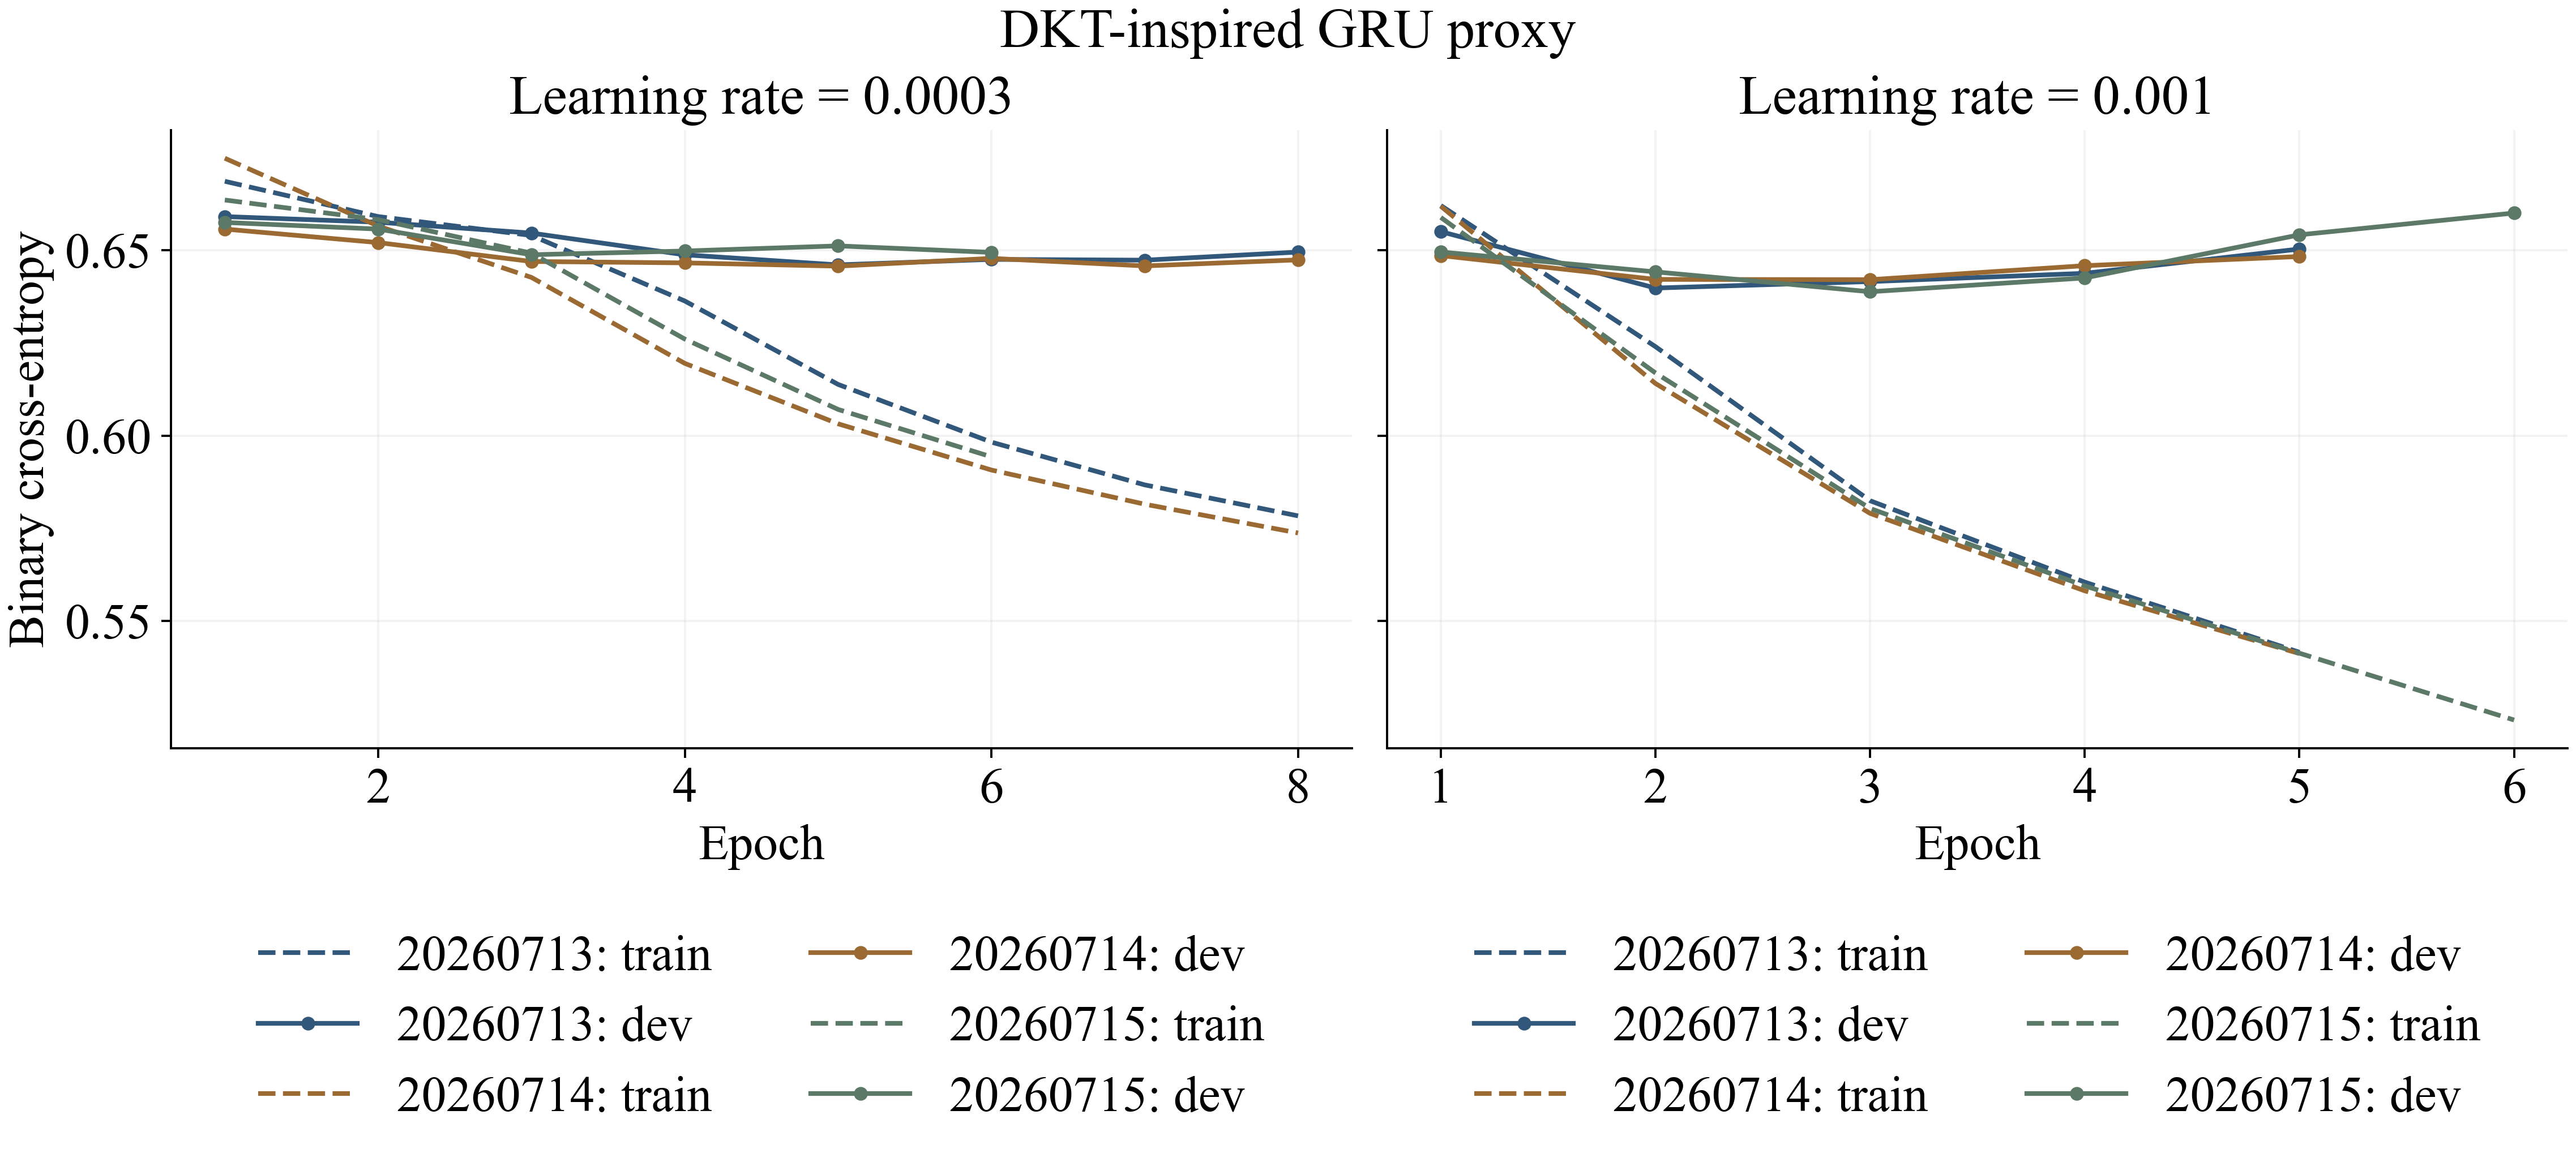

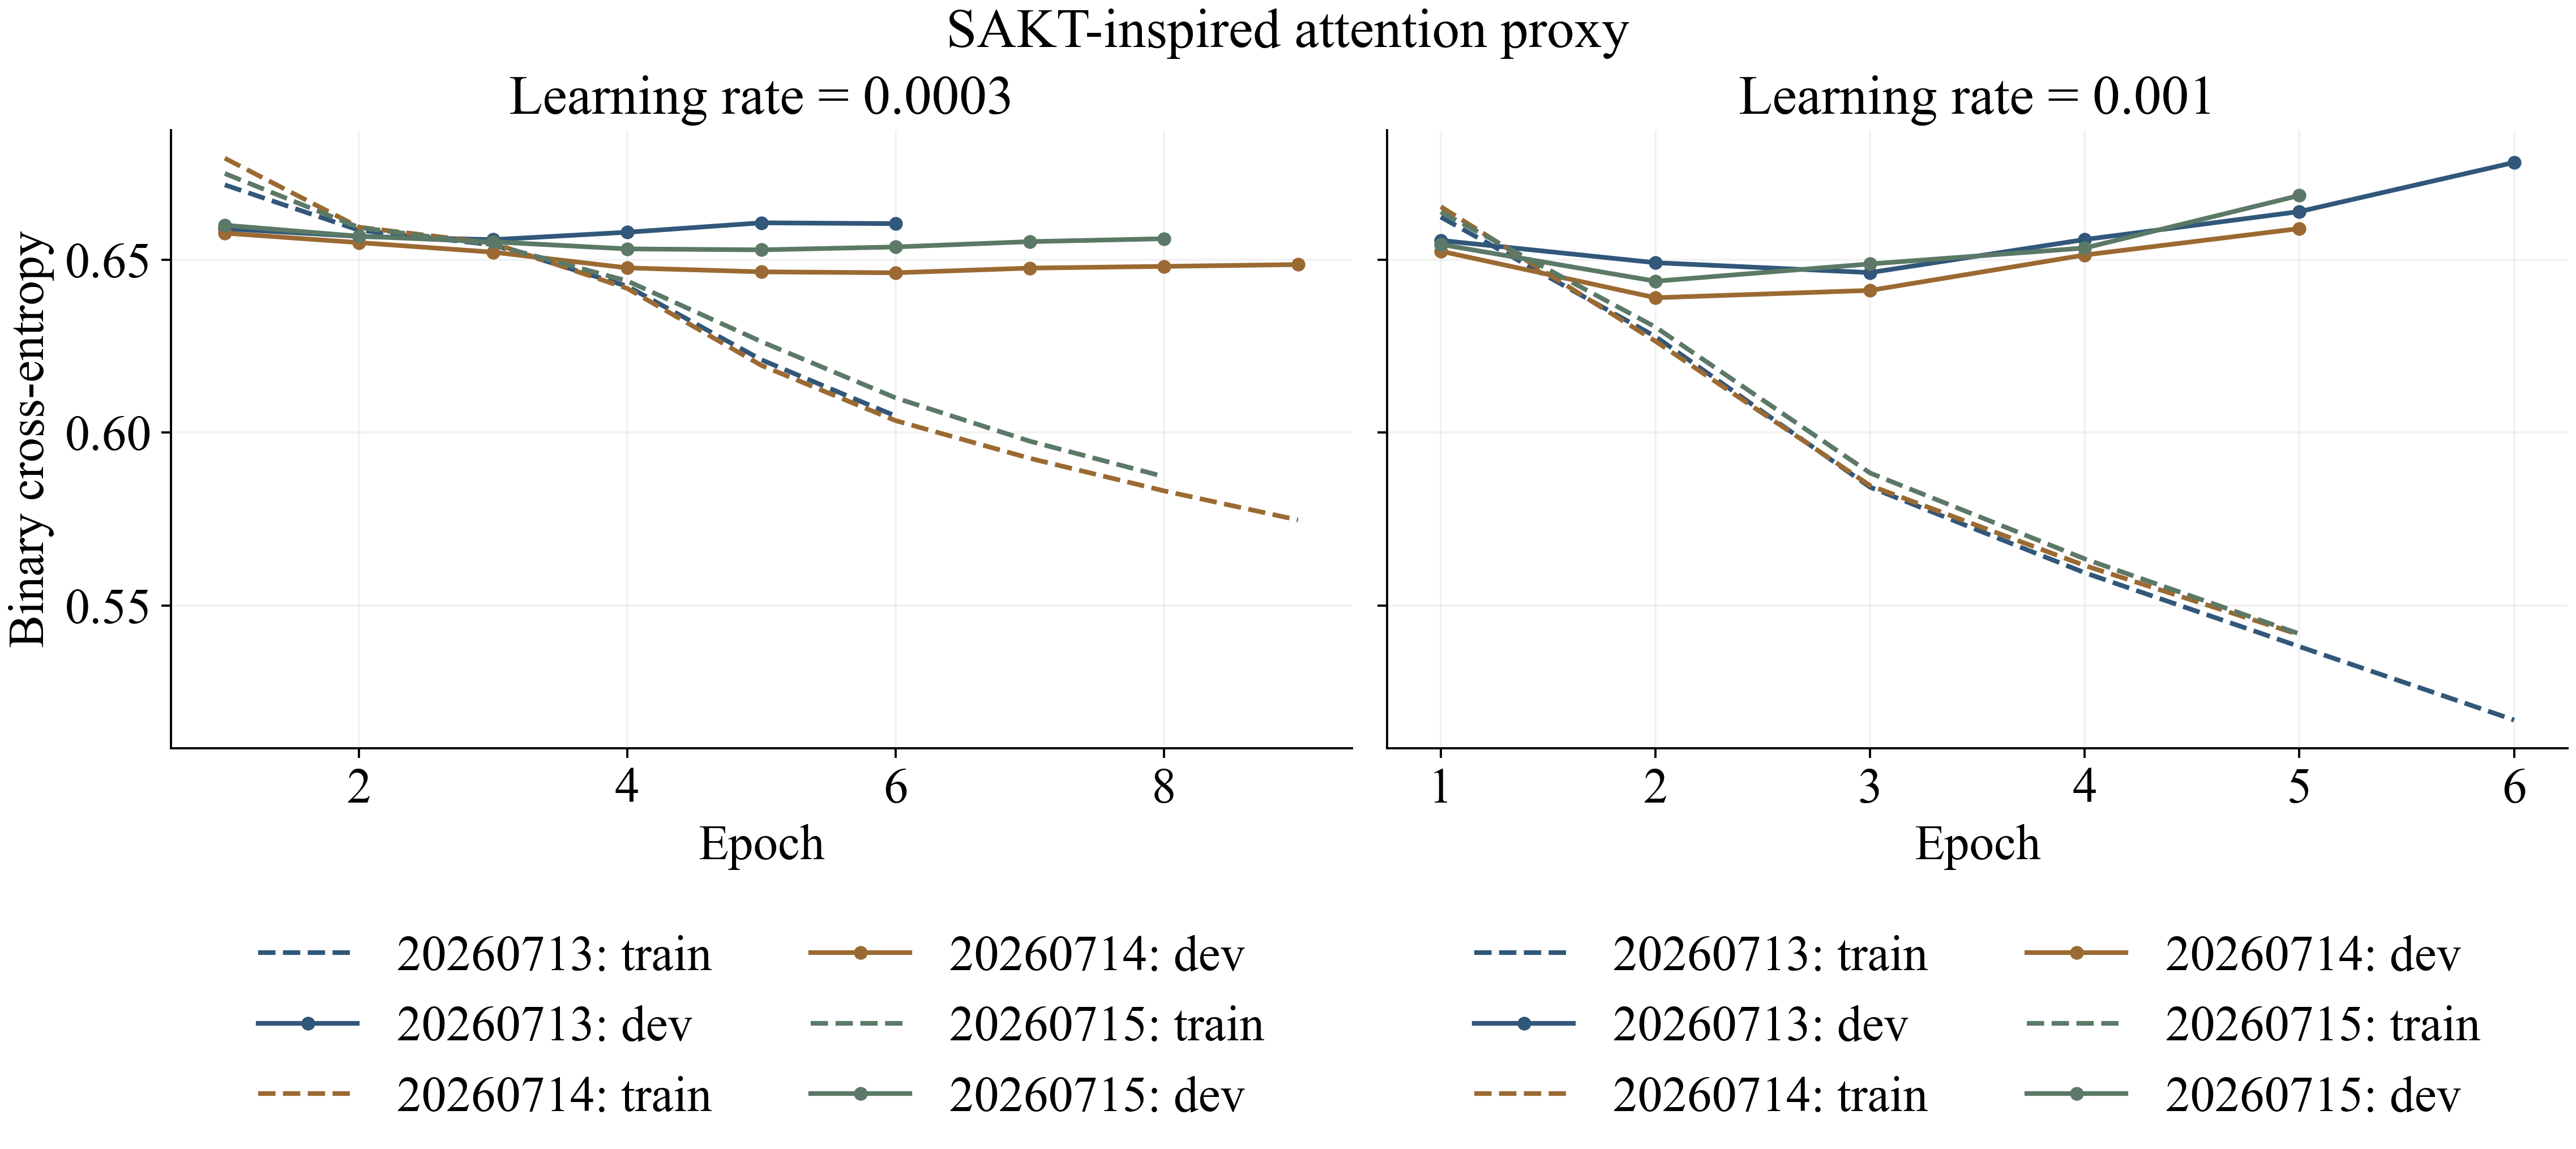

In [8]:
curves=pd.read_parquet(curve_path)
for model,g in curves.groupby("model",sort=False):
    fig,axes=plt.subplots(1,2,figsize=(13,5.8),layout="constrained",sharey=True)
    for ax,(rate,h) in zip(axes,g.groupby("learning_rate",sort=True)):
        colors=["#31577A","#9B6A32","#5B7966"]
        for color,(seed,k) in zip(colors,h.groupby("seed",sort=True)):
            ax.plot(k.epoch,k.train_loss,color=color,linestyle="--",linewidth=1.7,label=f"{seed}: train")
            ax.plot(k.epoch,k.development_loss,color=color,marker="o",markersize=4,linewidth=1.7,label=f"{seed}: dev")
        ax.set_title(f"Learning rate = {rate:g}");ax.set_xlabel("Epoch");ax.grid(alpha=.15)
        ax.spines[["top","right"]].set_visible(False)
        ax.legend(loc="upper center",bbox_to_anchor=(.5,-.23),ncol=2,frameon=False)
    axes[0].set_ylabel("Binary cross-entropy")
    fig.suptitle(model)
    save_canvas(fig,"sequence_learning_"+("gru" if "GRU" in model else "sakt"))

## Fixed-split predictive results
The same row identifiers are checked across models before metrics are computed. These values must not be subtracted from the monthly primary estimand.

In [9]:
import revision_models as rm
sequence_predictions=pd.read_parquet(prediction_path)
reference=None;rows=[]
for (model,seed),g in sequence_predictions.groupby(["model","seed"]):
    ids=frozenset(g.AnswerId)
    if reference is None:reference=ids
    assert ids==reference
    rows.append({"Model":model,"Seed":seed,"N":len(g),**rm.metrics(g.y,g.p)})
sequence_metrics=pd.DataFrame(rows)
show_table(sequence_metrics.drop(columns="NA_reason"),"Supporting matched-information results",["Model","Seed","N"],width=4)

**Supporting matched-information results**

Model,Seed,N,ROC_AUC,AP_correct,AP_incorrect,Log_Loss
DKT-inspired GRU proxy,20260713,143565,0.609506,0.726087,0.44904,0.633731
DKT-inspired GRU proxy,20260714,143565,0.622286,0.736298,0.459431,0.630106
DKT-inspired GRU proxy,20260715,143565,0.632315,0.745373,0.469956,0.626378
HGB100,20260713,143565,0.729958,0.829599,0.567699,0.571178
HGB100,20260714,143565,0.729958,0.829599,0.567699,0.571178
HGB100,20260715,143565,0.729958,0.829599,0.567699,0.571178
HGB80,20260713,143565,0.730068,0.829854,0.567933,0.571078
HGB80,20260714,143565,0.730068,0.829854,0.567933,0.571078
HGB80,20260715,143565,0.730068,0.829854,0.567933,0.571078
SAKT-inspired attention proxy,20260713,143565,0.639556,0.746493,0.47157,0.625784


Model,Seed,N,Brier,ECE15,Calibration_Intercept,Calibration_Slope
DKT-inspired GRU proxy,20260713,143565,0.221338,0.021707,-0.258788,1.232518
DKT-inspired GRU proxy,20260714,143565,0.21971,0.028299,-0.22079,1.125602
DKT-inspired GRU proxy,20260715,143565,0.218045,0.028566,-0.184146,1.071823
HGB100,20260713,143565,0.195107,0.010255,-0.041088,0.995553
HGB100,20260714,143565,0.195107,0.010255,-0.041088,0.995553
HGB100,20260715,143565,0.195107,0.010255,-0.041088,0.995553
HGB80,20260713,143565,0.195066,0.010206,-0.040845,0.994513
HGB80,20260714,143565,0.195066,0.010206,-0.040845,0.994513
HGB80,20260715,143565,0.195066,0.010206,-0.040845,0.994513
SAKT-inspired attention proxy,20260713,143565,0.217891,0.033145,-0.382593,1.347487


Model,Seed,N,Accuracy
DKT-inspired GRU proxy,20260713,143565,0.647839
DKT-inspired GRU proxy,20260714,143565,0.650242
DKT-inspired GRU proxy,20260715,143565,0.652011
HGB100,20260713,143565,0.697983
HGB100,20260714,143565,0.697983
HGB100,20260715,143565,0.697983
HGB80,20260713,143565,0.697802
HGB80,20260714,143565,0.697802
HGB80,20260715,143565,0.697802
SAKT-inspired attention proxy,20260713,143565,0.647337


## Comparative error structure and compute budget
Matched HGB controls and sequence proxies use identical target responses within this supporting experiment. Candidate seconds describe the recorded training runs, not deployment latency. Initialization hashes are retained as provenance outside the scientific tables.

In [10]:
averaged_sequence=sequence_predictions.groupby(["model","AnswerId"],as_index=False).agg(p=("p","mean"),y=("y","first"))
errors=averaged_sequence.assign(residual=averaged_sequence.y-averaged_sequence.p).pivot(index="AnswerId",columns="model",values="residual")
assert errors.notna().all().all()
similarity=errors.corr()
similarity.index.name="Model"
show_table(similarity.reset_index(),"Residual correlation on matched targets",["Model"],width=4)
resource_columns=["model","seed","learning_rate","epochs","stop_reason","seconds"]
show_table(registry.loc[registry.model.str.contains("proxy"),resource_columns],
           "Recorded sequence-candidate training effort",["model","seed"],width=4)
class_rows=[]
for (model,outcome),g in averaged_sequence.groupby(["model","y"]):
    class_rows.append({"Model":model,"Observed outcome":int(outcome),"N":len(g),
        "Mean predicted probability":g.p.mean(),"Mean squared error":((g.y-g.p)**2).mean()})
show_table(pd.DataFrame(class_rows),"Error decomposition by observed outcome",["Model","Observed outcome"],width=3)

**Residual correlation on matched targets**

model,Model,DKT-inspired GRU proxy,HGB100,HGB80,SAKT-inspired attention proxy
,DKT-inspired GRU proxy,1,0.94458,0.944354,0.994804
,HGB100,0.94458,1,0.999611,0.942164
,HGB80,0.944354,0.999611,1,0.941966
,SAKT-inspired attention proxy,0.994804,0.942164,0.941966,1


**Recorded sequence-candidate training effort**

model,seed,learning_rate,epochs,stop_reason,seconds
DKT-inspired GRU proxy,20260713,0.001,5,early_stopping_patience,69.966388
DKT-inspired GRU proxy,20260713,0.0003,8,early_stopping_patience,108.075042
SAKT-inspired attention proxy,20260713,0.001,6,early_stopping_patience,49.693802
SAKT-inspired attention proxy,20260713,0.0003,6,early_stopping_patience,47.149384
DKT-inspired GRU proxy,20260714,0.001,5,early_stopping_patience,67.421418
DKT-inspired GRU proxy,20260714,0.0003,8,early_stopping_patience,108.465862
SAKT-inspired attention proxy,20260714,0.001,5,early_stopping_patience,38.692391
SAKT-inspired attention proxy,20260714,0.0003,9,early_stopping_patience,70.399359
DKT-inspired GRU proxy,20260715,0.001,6,early_stopping_patience,80.512116
DKT-inspired GRU proxy,20260715,0.0003,6,early_stopping_patience,81.476232


**Error decomposition by observed outcome**

Model,Observed outcome,N,Mean predicted probability,Mean squared error
DKT-inspired GRU proxy,0,50609,0.65069,0.42788
DKT-inspired GRU proxy,1,92956,0.686131,0.102685
HGB100,0,50609,0.561802,0.343691
HGB100,1,92956,0.707111,0.114212
HGB80,0,50609,0.561688,0.343599
HGB80,1,92956,0.707261,0.114198
SAKT-inspired attention proxy,0,50609,0.657005,0.435095
SAKT-inspired attention proxy,1,92956,0.689034,0.100255


Neural tuning uses a fixed chronological development block rather than monthly nested folds. These saved sequence predictions are therefore a supporting matched-information check, not a nested-OOF competitor in the primary six-window estimate. No surrogate OOF predictions or missing training histories are invented.

## Interpretation and boundary
All saved candidates, not only the best-looking training curve, are displayed. This compact benchmark diagnoses the chosen information representation and local proxy implementations. It does not establish superiority over canonical sequence models or replace monthly refitting. Neural architecture-migration equality is a software check, not additional scientific evidence.